In [138]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [139]:
df=pd.read_csv("../../../data/processed/3_year/Avg_Top5_Leagues.csv")

In [140]:
df=df[df["position"] == "Forwards"].copy()

In [141]:
df=df[df['minutesplayed'] > 540]

In [142]:
df=df.drop(columns=fl.goalkeeper_features)

In [143]:
df=df.drop(columns=fl.discipline_features)

In [144]:
df=df.drop(columns=[
    "fouls",
    "fouls_per90",
    "tackles",
    "tackleswon",
    "tackleswonpercentage",
    "possessionwonattthird",
    "clearances",
    "blockedshots",
    "dribbledpast",
    "errorleadtoshot",
    "errorleadtogoal",
    "tackles_per90",
    "tackleswon_per90",
    "possessionwonattthird_per90",
    "clearances_per90",
    "blockedshots_per90",
    "dribbledpast_per90",
    "errorleadtoshot_per90",
    "errorleadtogoal_per90",
    
    ])

In [145]:
df.shape

(417, 144)

In [146]:
df=df.drop(columns=[
    'rating',
    'accuratepassespercentage', 
    'opp_half_pass_pct',
])

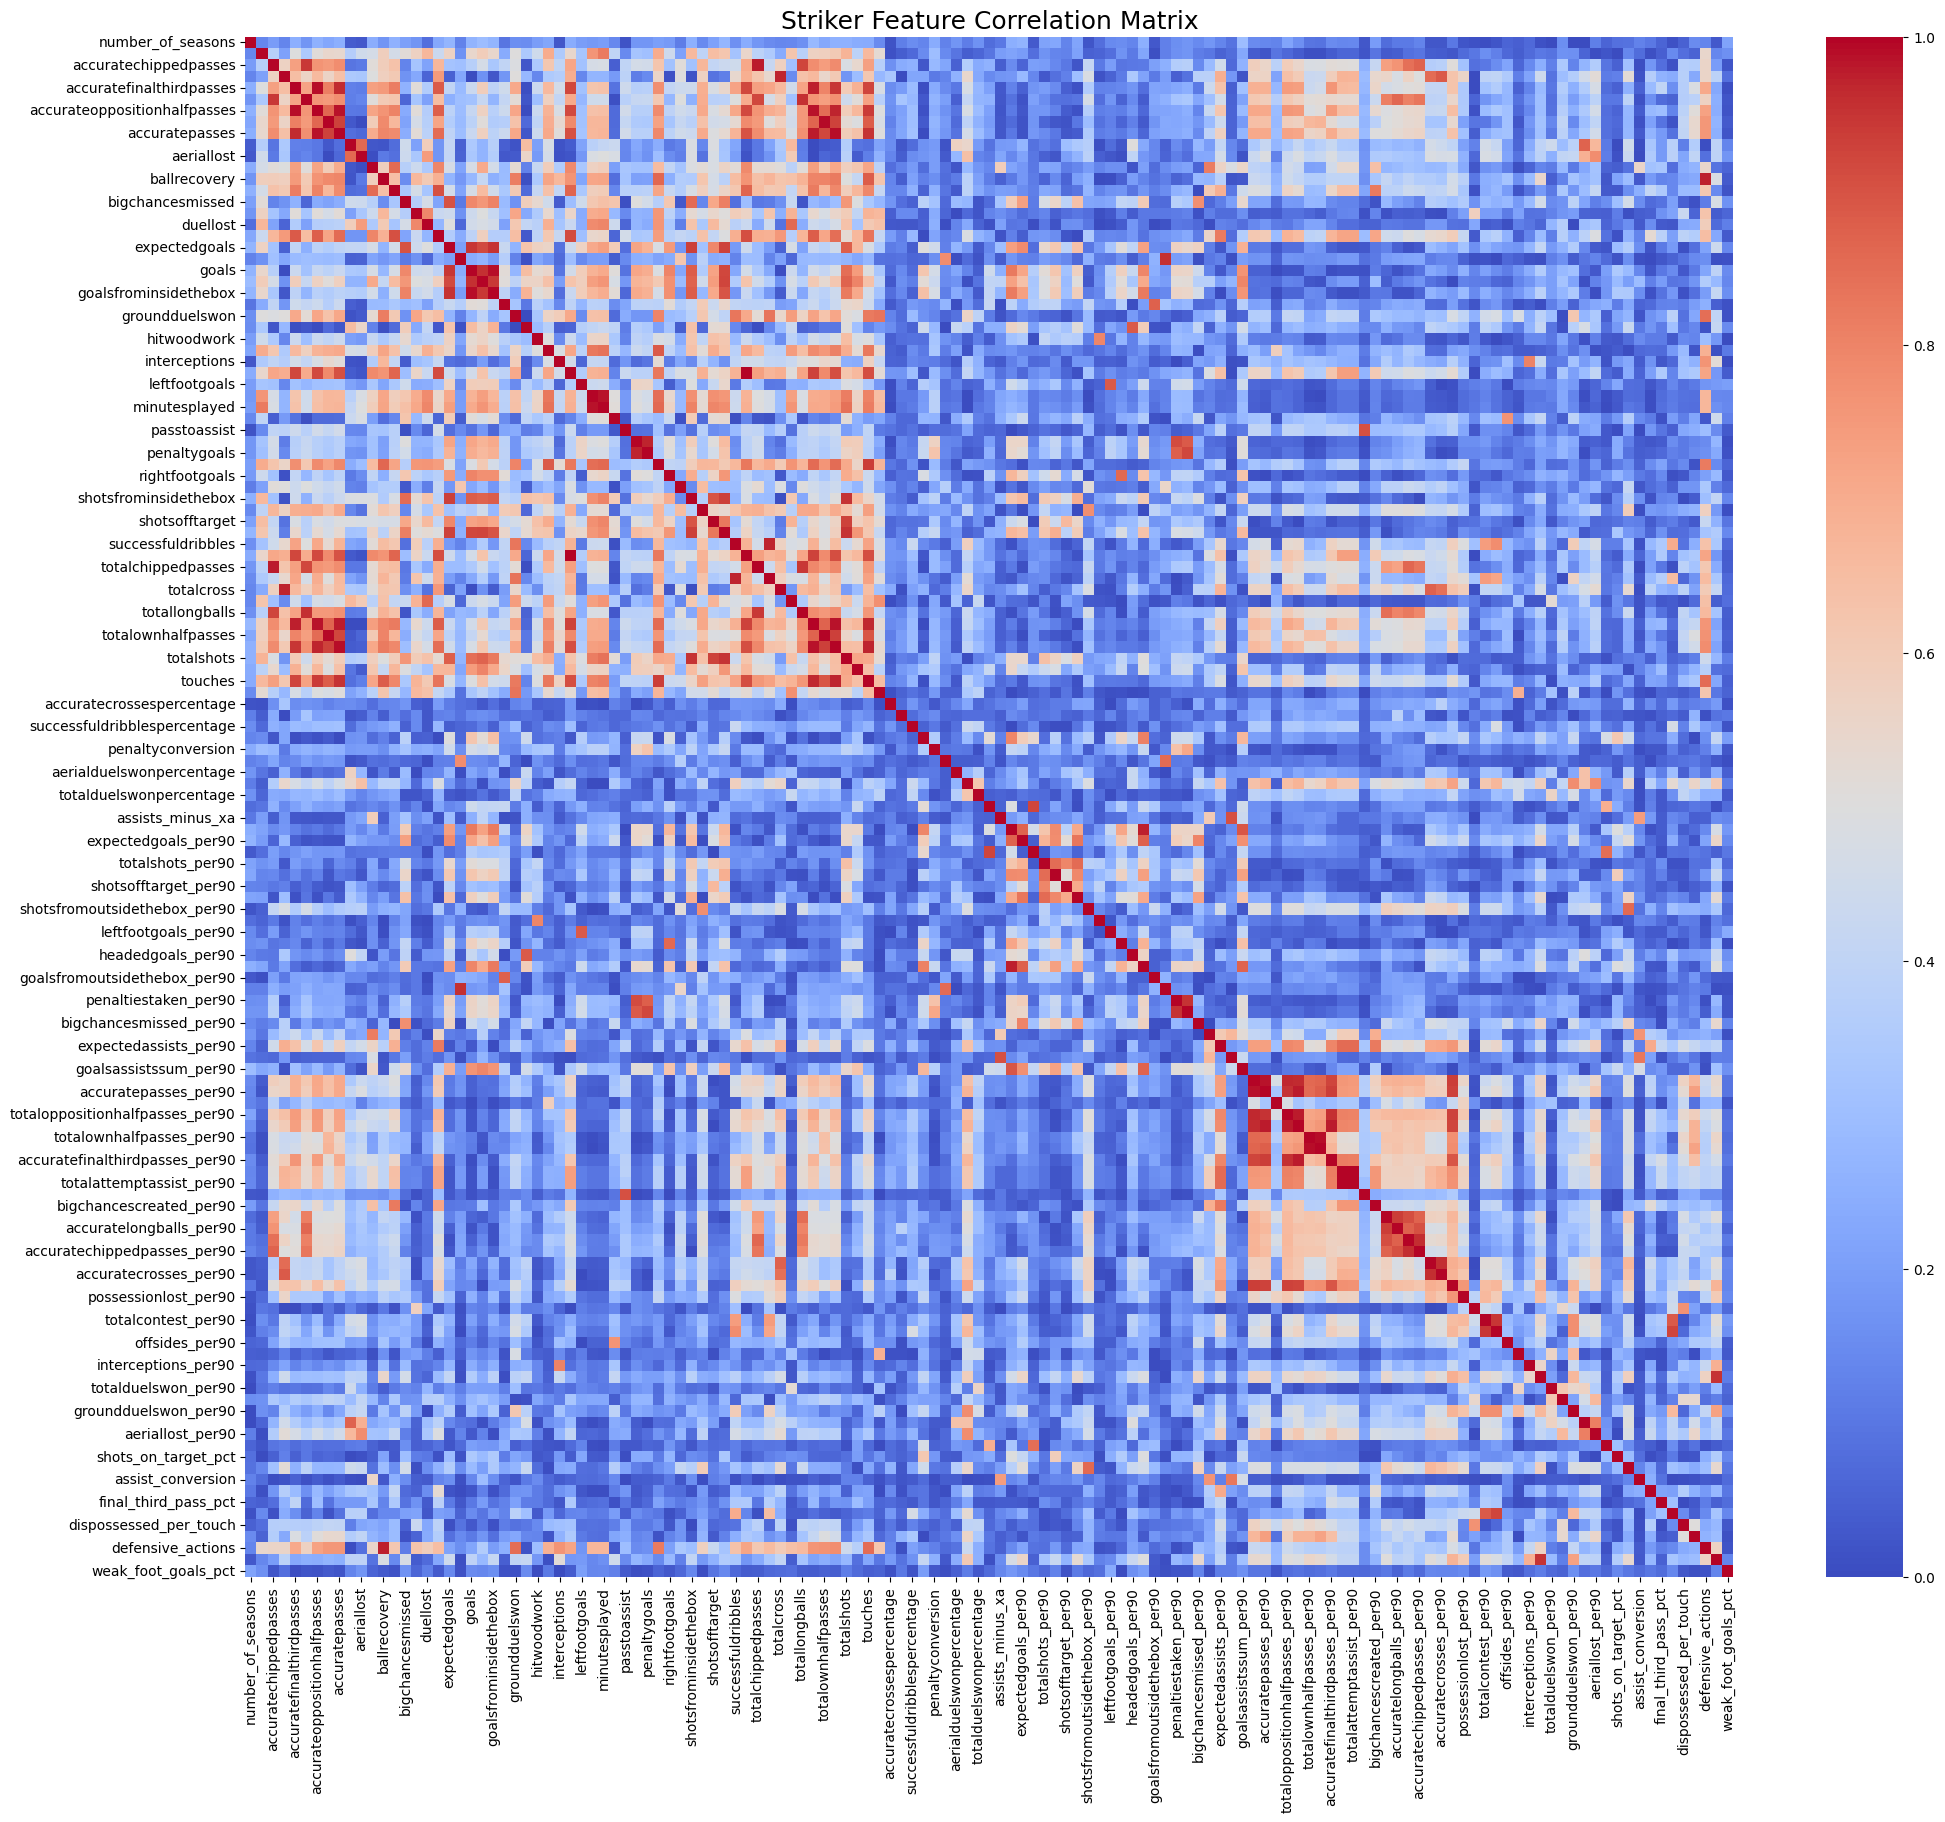

In [147]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [148]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keypasses,totalattemptassist,0.999745
1,keypasses_per90,totalattemptassist_per90,0.999368
2,accurateownhalfpasses,totalownhalfpasses,0.994018
3,totalownhalfpasses_per90,accurateownhalfpasses_per90,0.990413
4,goals,goalsfrominsidethebox,0.990199
5,accuratefinalthirdpasses,accurateoppositionhalfpasses,0.989106
6,accuratepasses,totalpasses,0.988498
7,accurateoppositionhalfpasses,accuratepasses,0.987842
8,totaloppositionhalfpasses,totalpasses,0.986065
9,matchesstarted,minutesplayed,0.986065


In [149]:
drops = [
    'appearances', 'matchesstarted', 'totwappearances',
    'goals', 'assists', 'expectedgoals', 'expectedassists', 'goalsassistssum',
    'touches', 'totalpasses', 'accuratepasses', 'inaccuratepasses',
    'totalownhalfpasses', 'accurateownhalfpasses','goals_minus_xg','assists_minus_xa',
    'totaloppositionhalfpasses', 'accurateoppositionhalfpasses',
    'accuratefinalthirdpasses', 'totalattemptassist', 'passtoassist',
    'totalshots', 'shotsfrominsidethebox', 'shotsfromoutsidethebox', 
    'shotsontarget', 'shotsofftarget', 'bigchancescreated', 'bigchancesmissed',
    'goalsfrominsidethebox', 'goalsfromoutsidethebox', 'headedgoals', 
    'leftfootgoals', 'rightfootgoals', 'freekickgoal', 'penaltygoals', 'penaltiestaken',
    'totalcross', 'accuratecrosses', 'totallongballs', 'accuratelongballs', 
    'totalchippedpasses', 'accuratechippedpasses',
    'totalduelswon', 'groundduelswon', 'aerialduelswon', 'aeriallost', 'duellost',
    'successfuldribbles', 'dispossessed', 'wasfouled', 'totalcontest',
    'interceptions', 'ballrecovery', 'defensive_actions', 'hitwoodwork',

    'dribbles_per_touch', 'setpiececonversion', 'shotfromsetpiece', 
    'goals_per_xg', 'goalsassistssum_per90', 'totalownhalfpasses_per90', 
    'accurateownhalfpasses_per90', 'totaloppositionhalfpasses_per90', 
    'accurateownhalfpasses_per90', 'totalpasses_per90', 'accuratepasses_per90',
    'totalchippedpasses_per90', 'accuratechippedpasses_per90', 'leftfootgoals_per90', 
    'rightfootgoals_per90', 'hitwoodwork_per90', 'freekickgoal_per90', 
    'penaltiestaken_per90', 'totalcontest_per90', 'totalattemptassist_per90',
    'goalsfrominsidethebox_per90', 'dispossessed_per_touch', 'bigchancesmissed_per90',
    'totalshots_per90', 'totalduelswon_per90',
    
    'accurateoppositionhalfpasses_per90', 'accuratefinalthirdpasses_per90',     
    'keypasses_per90','accuratecrosses_per90',          
    'accuratelongballs_per90', 'ballrecovery_per90'                  
]

df=df.drop(columns=drops)

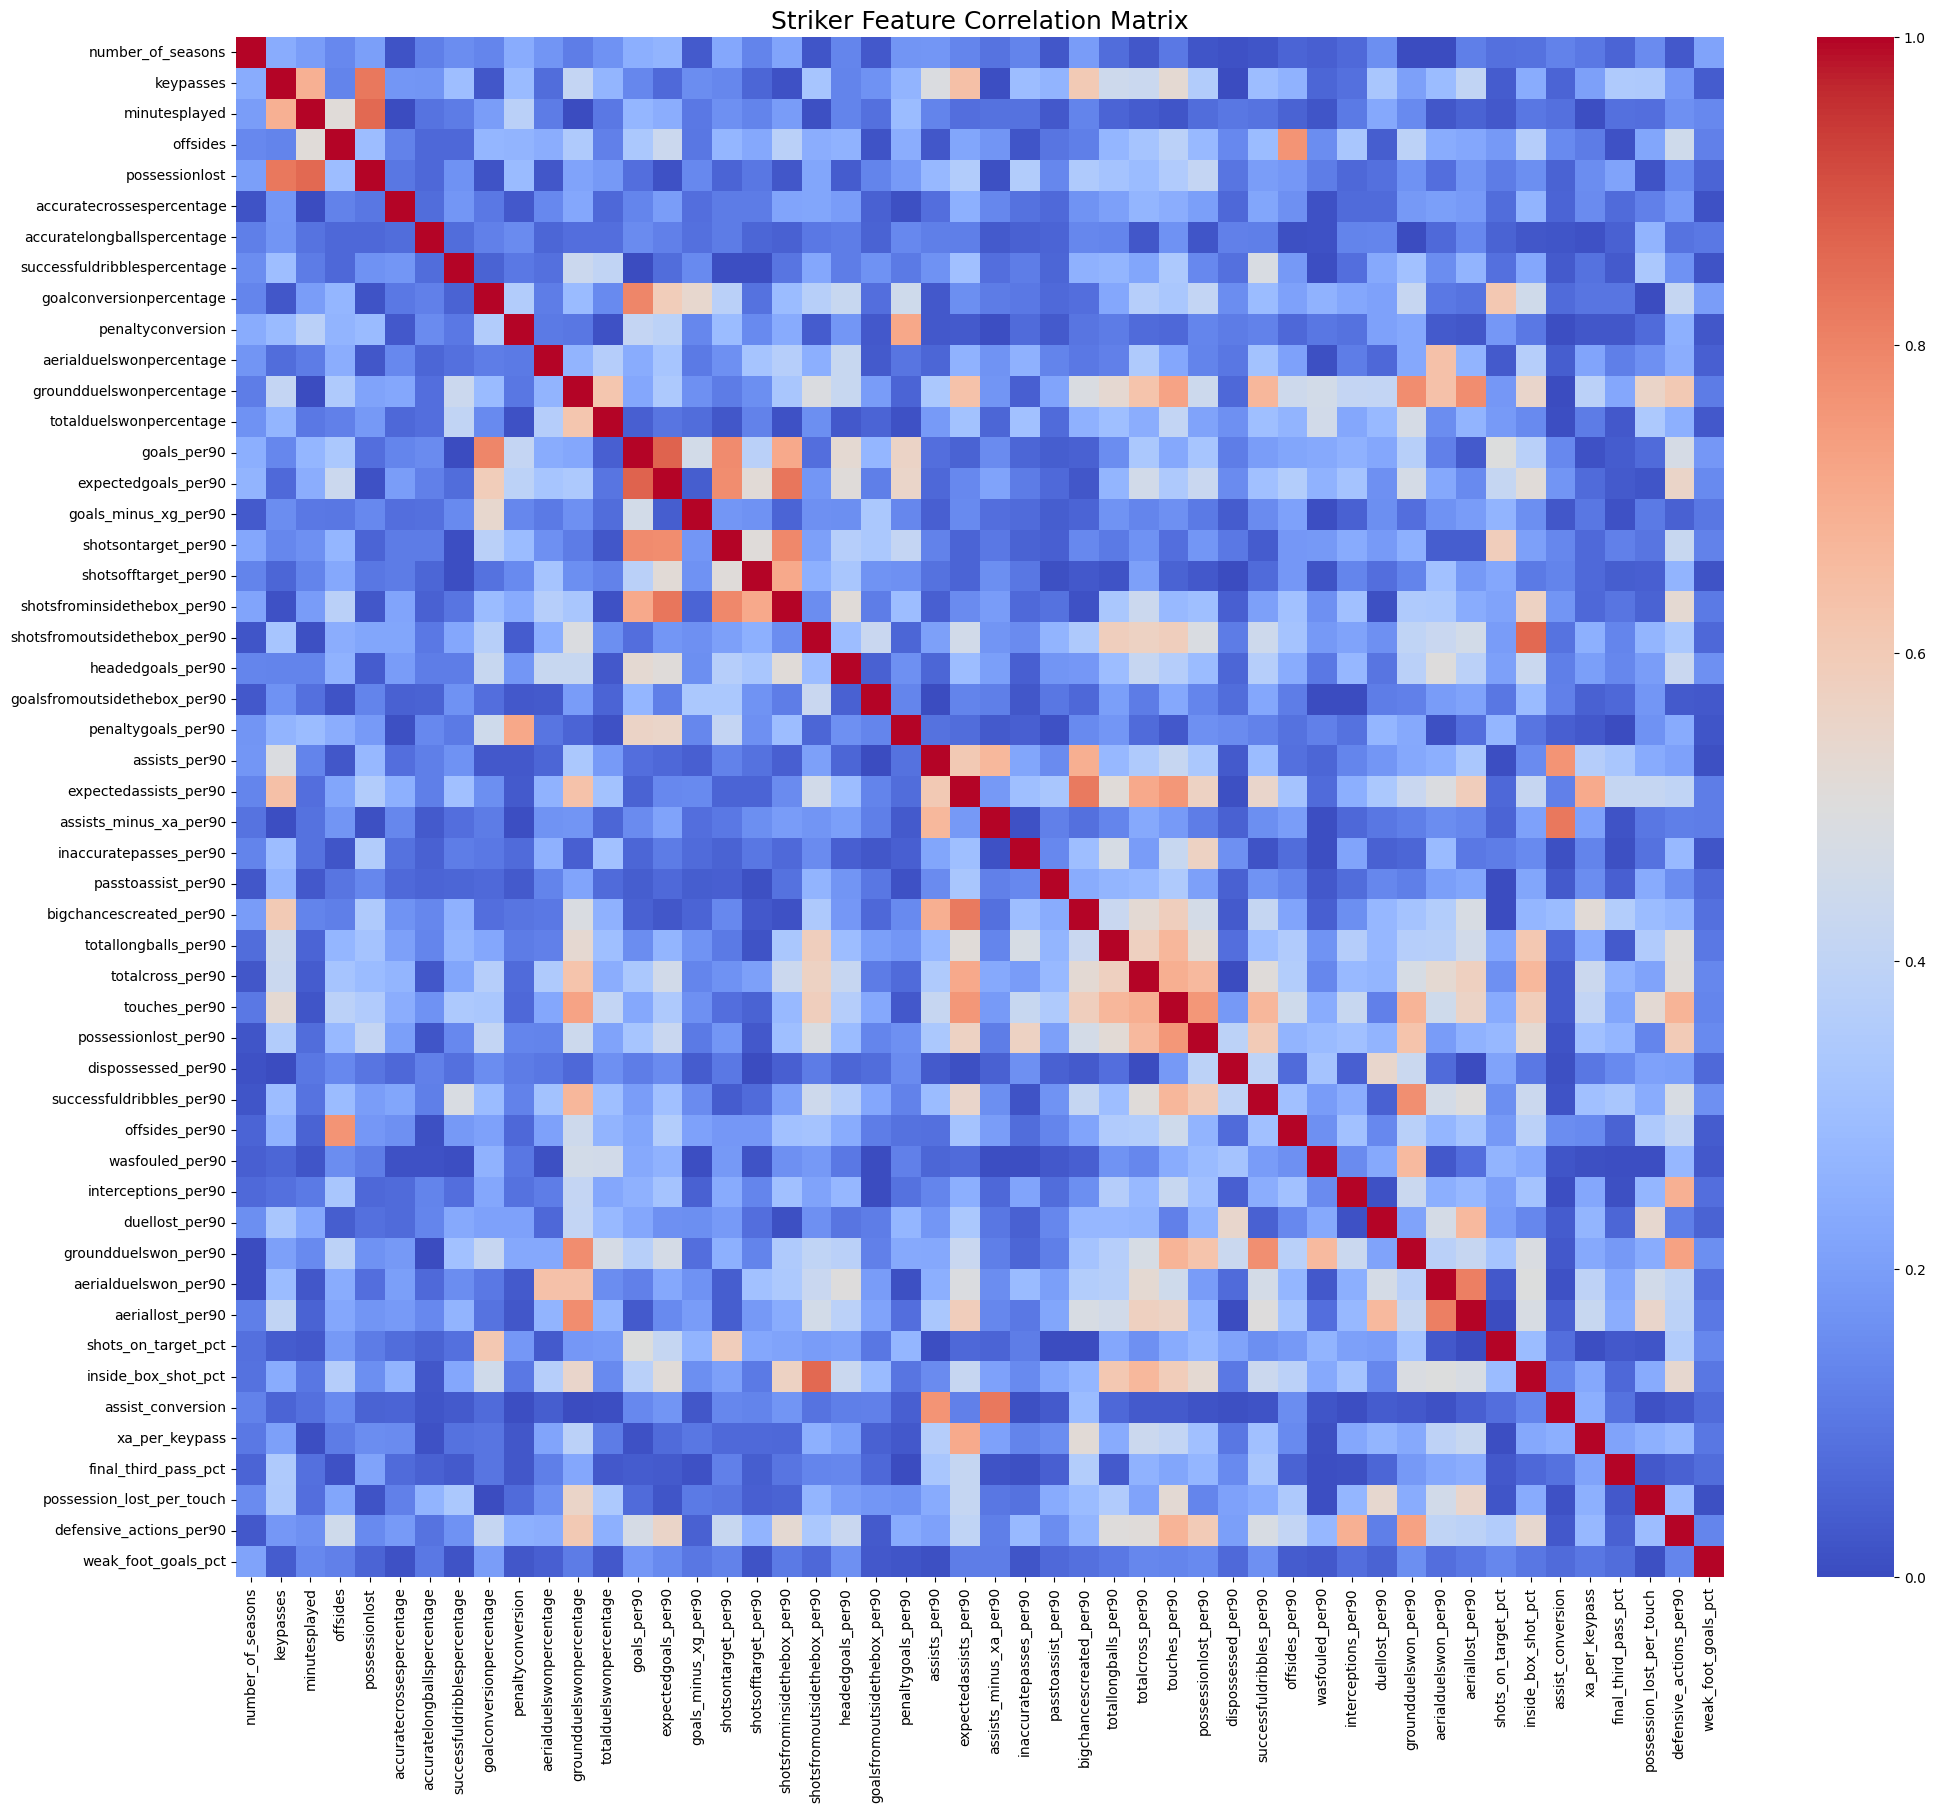

In [150]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [151]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,goals_per90,expectedgoals_per90,0.868679
1,shotsfromoutsidethebox_per90,inside_box_shot_pct,0.858999
2,minutesplayed,possessionlost,0.856111
3,expectedgoals_per90,shotsfrominsidethebox_per90,0.828394
4,assists_minus_xa_per90,assist_conversion,0.827860
5,keypasses,possessionlost,0.825314
6,expectedassists_per90,bigchancescreated_per90,0.823072
7,aerialduelswon_per90,aeriallost_per90,0.809249


In [152]:
df.shape

(417, 56)

In [153]:
df['weak_foot_goals_pct'] = df['weak_foot_goals_pct'].fillna(0)
df['assist_conversion'] = df['assist_conversion'].fillna(0)
df['xa_per_keypass'] = df['xa_per_keypass'].fillna(0)

In [154]:
df.select_dtypes(include=['number']).isna().sum().sum()

np.int64(0)

In [155]:
df.to_csv("../../../data/processed/3_year/Forwards/Avg_Top5_Forwards.csv",index=False)